In [2]:
from pathlib import Path
import sys

project_root = Path(r"E:\slde-aft")
src_path = project_root / "src"
pkb_math_path = src_path / "pkb_math.py"

print("Current working directory:", Path.cwd())
print("Project root exists:", project_root.exists())
print("src exists:", src_path.exists())
print("pkb_math.py exists:", pkb_math_path.exists())

if not pkb_math_path.exists():
    raise FileNotFoundError(
        f"Cannot find the expected file: {pkb_math_path}"
    )

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pkb_math import (
    DEFAULT_SHRINKAGE,
    conservative_noisy_or,
    conflict_adjusted_confidence,
    final_confidence,
    max_merge,
    mean_aggregation,
    standard_noisy_or,
)

print("pkb_math imported successfully.")
print("Shrinkage lambda:", DEFAULT_SHRINKAGE)

Current working directory: e:\slde-aft\notebooks
Project root exists: True
src exists: True
pkb_math.py exists: True
pkb_math imported successfully.
Shrinkage lambda: 0.75


In [6]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path(r"E:\slde-aft")
src_path = project_root / "src"
output_dir = project_root / "outputs" / "dec003_scaled"

output_dir.mkdir(parents=True, exist_ok=True)

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pkb_math import (
    DEFAULT_SHRINKAGE,
    conservative_noisy_or,
    conflict_adjusted_confidence,
    final_confidence,
    max_merge,
    mean_aggregation,
    standard_noisy_or,
)

print("Current notebook directory:", Path.cwd())
print("Project root exists:", project_root.exists())
print("Source folder exists:", src_path.exists())
print("Output directory:", output_dir)
print("Output directory exists:", output_dir.exists())
print("Imported pkb_math successfully.")
print("Shrinkage lambda:", DEFAULT_SHRINKAGE)

Current notebook directory: e:\slde-aft\notebooks
Project root exists: True
Source folder exists: True
Output directory: E:\slde-aft\outputs\dec003_scaled
Output directory exists: True
Imported pkb_math successfully.
Shrinkage lambda: 0.75


In [7]:
EXPERIMENT_ID = "DEC003_SCALED_V1"

SEEDS = [42, 43, 44]

SCENARIOS = {
    "no_conflict": {
        "conflict_rate": 0.00,
        "description": "No functional slots contain competing object candidates.",
    },
    "moderate_conflict": {
        "conflict_rate": 0.25,
        "description": "Twenty-five percent of functional slots contain a competitor.",
    },
    "high_conflict": {
        "conflict_rate": 0.50,
        "description": "Fifty percent of functional slots contain a competitor.",
    },
}

N_SLOTS = 150
FUNCTIONAL_SLOT_SHARE = 0.50
MAX_OBSERVATIONS_PER_TRIPLE = 5
POSITIVE_CONFIDENCE_RANGE = (0.60, 0.95)
NEGATIVE_CONFIDENCE_RANGE = (0.15, 0.75)
THRESHOLDS = np.round(np.arange(0.00, 1.01, 0.01), 2)
CALIBRATION_BINS = np.linspace(0.0, 1.0, 11)

config_df = pd.DataFrame([
    {
        "experiment_id": EXPERIMENT_ID,
        "seeds": ",".join(map(str, SEEDS)),
        "scenario": scenario_name,
        "conflict_rate": settings["conflict_rate"],
        "n_slots": N_SLOTS,
        "functional_slot_share": FUNCTIONAL_SLOT_SHARE,
        "max_observations_per_triple": MAX_OBSERVATIONS_PER_TRIPLE,
        "positive_confidence_range": str(POSITIVE_CONFIDENCE_RANGE),
        "negative_confidence_range": str(NEGATIVE_CONFIDENCE_RANGE),
        "shrinkage": DEFAULT_SHRINKAGE,
        "threshold_count": len(THRESHOLDS),
        "calibration_bin_count": len(CALIBRATION_BINS) - 1,
        "description": settings["description"],
    }
    for scenario_name, settings in SCENARIOS.items()
])

display(config_df)

config_path = output_dir / "experiment_config.csv"
config_df.to_csv(config_path, index=False, encoding="utf-8")

print("Saved configuration to:", config_path)

,experiment_id,seeds,scenario,conflict_rate,n_slots,functional_slot_share,max_observations_per_triple,positive_confidence_range,negative_confidence_range,shrinkage,threshold_count,calibration_bin_count,description
0,DEC003_SCALED_V1,"42,43,44",no_conflict,0.00,150,0.5,5,"(0.6, 0.95)","(0.15, 0.75)",0.75,101,10,No functional slots contain competing object c...
1,DEC003_SCALED_V1,"42,43,44",moderate_conflict,0.25,150,0.5,5,"(0.6, 0.95)","(0.15, 0.75)",0.75,101,10,Twenty-five percent of functional slots contai...
2,DEC003_SCALED_V1,"42,43,44",high_conflict,0.50,150,0.5,5,"(0.6, 0.95)","(0.15, 0.75)",0.75,101,10,Fifty percent of functional slots contain a co...


Saved configuration to: E:\slde-aft\outputs\dec003_scaled\experiment_config.csv


In [8]:
def sample_confidences(
    rng,
    gold_label,
    max_observations,
    positive_range,
    negative_range,
):
    observation_count = int(rng.integers(1, max_observations + 1))

    if gold_label == 1:
        values = rng.uniform(
            positive_range[0],
            positive_range[1],
            size=observation_count,
        )
    else:
        values = rng.uniform(
            negative_range[0],
            negative_range[1],
            size=observation_count,
        )

    return [round(float(value), 6) for value in values]


def generate_controlled_pkb_run(
    experiment_id,
    scenario_name,
    conflict_rate,
    seed,
    n_slots=N_SLOTS,
    functional_slot_share=FUNCTIONAL_SLOT_SHARE,
    max_observations_per_triple=MAX_OBSERVATIONS_PER_TRIPLE,
    positive_confidence_range=POSITIVE_CONFIDENCE_RANGE,
    negative_confidence_range=NEGATIVE_CONFIDENCE_RANGE,
):
    rng = np.random.default_rng(seed)

    run_id = f"{experiment_id}__{scenario_name}__seed_{seed}"

    slot_rows = []
    triple_rows = []
    observation_rows = []

    functional_slot_count = int(round(n_slots * functional_slot_share))
    functional_slot_indices = set(
        rng.choice(
            np.arange(n_slots),
            size=functional_slot_count,
            replace=False,
        ).tolist()
    )

    functional_indices = np.array(sorted(functional_slot_indices))
    conflict_slot_count = int(
        round(len(functional_indices) * conflict_rate)
    )

    if conflict_slot_count > 0:
        conflict_slot_indices = set(
            rng.choice(
                functional_indices,
                size=conflict_slot_count,
                replace=False,
            ).tolist()
        )
    else:
        conflict_slot_indices = set()

    for slot_index in range(n_slots):
        subject = f"Entity-{slot_index:03d}"
        predicate = (
            "functional_attribute"
            if slot_index in functional_slot_indices
            else "multi_valued_attribute"
        )

        functional_predicate = slot_index in functional_slot_indices
        has_conflict = slot_index in conflict_slot_indices

        true_object = f"value_true_{slot_index:03d}"

        slot_rows.append({
            "experiment_id": experiment_id,
            "run_id": run_id,
            "scenario": scenario_name,
            "seed": seed,
            "slot_id": f"{subject}|{predicate}",
            "subject": subject,
            "predicate": predicate,
            "functional_predicate": functional_predicate,
            "has_conflict": has_conflict,
        })

        candidate_objects = [
            {
                "object": true_object,
                "gold_label": 1,
                "candidate_type": "true",
            }
        ]

        if has_conflict:
            candidate_objects.append({
                "object": f"value_false_{slot_index:03d}",
                "gold_label": 0,
                "candidate_type": "competitor_false",
            })

        if not functional_predicate:
            include_nonfunctional_extra = bool(rng.integers(0, 2))

            if include_nonfunctional_extra:
                candidate_objects.append({
                    "object": f"value_extra_{slot_index:03d}",
                    "gold_label": 1,
                    "candidate_type": "additional_true_multivalued",
                })

        for candidate in candidate_objects:
            confidences = sample_confidences(
                rng=rng,
                gold_label=candidate["gold_label"],
                max_observations=max_observations_per_triple,
                positive_range=positive_confidence_range,
                negative_range=negative_confidence_range,
            )

            triple_key = (
                f"{subject}|{predicate}|{candidate['object']}"
            )

            triple_rows.append({
                "experiment_id": experiment_id,
                "run_id": run_id,
                "scenario": scenario_name,
                "seed": seed,
                "slot_id": f"{subject}|{predicate}",
                "triple_key": triple_key,
                "subject": subject,
                "predicate": predicate,
                "object": candidate["object"],
                "gold_label": candidate["gold_label"],
                "candidate_type": candidate["candidate_type"],
                "functional_predicate": functional_predicate,
                "observation_count": len(confidences),
                "observation_confidences": str(confidences),
            })

            for observation_index, confidence in enumerate(
                confidences,
                start=1,
            ):
                observation_rows.append({
                    "experiment_id": experiment_id,
                    "run_id": run_id,
                    "scenario": scenario_name,
                    "seed": seed,
                    "slot_id": f"{subject}|{predicate}",
                    "triple_key": triple_key,
                    "subject": subject,
                    "predicate": predicate,
                    "object": candidate["object"],
                    "gold_label": candidate["gold_label"],
                    "candidate_type": candidate["candidate_type"],
                    "functional_predicate": functional_predicate,
                    "observation_index": observation_index,
                    "observation_confidence": confidence,
                    "source_id": f"synthetic_source_{observation_index}",
                    "iteration": observation_index,
                    "provenance": (
                        f"Controlled synthetic observation "
                        f"{observation_index} for {triple_key}"
                    ),
                })

    slots_df = pd.DataFrame(slot_rows)
    triples_df = pd.DataFrame(triple_rows)
    observations_df = pd.DataFrame(observation_rows)

    return slots_df, triples_df, observations_df

In [9]:
all_slots = []
all_triples = []
all_observations = []

for scenario_name, scenario_settings in SCENARIOS.items():
    for seed in SEEDS:
        slots_df, triples_df, observations_df = generate_controlled_pkb_run(
            experiment_id=EXPERIMENT_ID,
            scenario_name=scenario_name,
            conflict_rate=scenario_settings["conflict_rate"],
            seed=seed,
        )

        all_slots.append(slots_df)
        all_triples.append(triples_df)
        all_observations.append(observations_df)

slots_all_df = pd.concat(all_slots, ignore_index=True)
triples_all_df = pd.concat(all_triples, ignore_index=True)
observations_all_df = pd.concat(
    all_observations,
    ignore_index=True,
)

print("Runs:", triples_all_df["run_id"].nunique())
print("Slots:", len(slots_all_df))
print("Candidate triples:", len(triples_all_df))
print("Observations:", len(observations_all_df))
print()

display(
    triples_all_df.groupby(
        ["scenario", "seed"]
    ).agg(
        candidate_triples=("triple_key", "count"),
        gold_positive_triples=("gold_label", "sum"),
        functional_triples=("functional_predicate", "sum"),
        mean_observations=("observation_count", "mean"),
    ).reset_index().round(3)
)

Runs: 9
Slots: 1350
Candidate triples: 1858
Observations: 5555



,scenario,seed,candidate_triples,gold_positive_triples,functional_triples,mean_observations
0,high_conflict,42,221,183,113,2.955
1,high_conflict,43,230,192,113,3.113
2,high_conflict,44,225,187,113,3.089
3,moderate_conflict,42,206,187,94,2.917
4,moderate_conflict,43,206,187,94,3.019
5,moderate_conflict,44,202,183,94,2.946
6,no_conflict,42,188,188,75,3.016
7,no_conflict,43,194,194,75,2.974
8,no_conflict,44,186,186,75,2.844


In [10]:
slots_path = output_dir / "slots.csv"
triples_path = output_dir / "candidate_triples.csv"
observations_path = output_dir / "observations.csv"

slots_all_df.to_csv(slots_path, index=False, encoding="utf-8")
triples_all_df.to_csv(triples_path, index=False, encoding="utf-8")
observations_all_df.to_csv(
    observations_path,
    index=False,
    encoding="utf-8",
)

print("Saved slots to:", slots_path)
print("Saved candidate triples to:", triples_path)
print("Saved observations to:", observations_path)

Saved slots to: E:\slde-aft\outputs\dec003_scaled\slots.csv
Saved candidate triples to: E:\slde-aft\outputs\dec003_scaled\candidate_triples.csv
Saved observations to: E:\slde-aft\outputs\dec003_scaled\observations.csv


In [11]:
def calculate_scores_for_run(
    triples_df,
    observations_df,
    shrinkage=DEFAULT_SHRINKAGE,
):
    run_id = triples_df["run_id"].iloc[0]

    observation_groups = (
        observations_df
        .groupby("triple_key")["observation_confidence"]
        .apply(list)
        .to_dict()
    )

    competitor_counts = (
        triples_df
        .groupby("slot_id")["object"]
        .nunique()
        .sub(1)
        .to_dict()
    )

    score_rows = []

    for _, triple in triples_df.iterrows():
        triple_key = triple["triple_key"]
        confidences = observation_groups[triple_key]
        competitor_count = int(
            competitor_counts[triple["slot_id"]]
        )

        support = conservative_noisy_or(
            confidences,
            shrinkage=shrinkage,
        )

        final_score = final_confidence(
            confidences=confidences,
            competitor_count=competitor_count,
            shrinkage=shrinkage,
            functional_predicate=bool(
                triple["functional_predicate"]
            ),
        )

        score_rows.append({
            **triple.to_dict(),
            "competitor_count": competitor_count,
            "max_merge": max_merge(confidences),
            "mean_aggregation": mean_aggregation(confidences),
            "standard_noisy_or": standard_noisy_or(confidences),
            "conservative_noisy_or": support,
            "conservative_noisy_or_conflict_adjusted": final_score,
        })

    return pd.DataFrame(score_rows)

In [12]:
score_frames = []

for run_id, run_triples_df in triples_all_df.groupby("run_id"):
    run_observations_df = observations_all_df[
        observations_all_df["run_id"] == run_id
    ].copy()

    run_scores_df = calculate_scores_for_run(
        triples_df=run_triples_df.copy(),
        observations_df=run_observations_df,
        shrinkage=DEFAULT_SHRINKAGE,
    )

    score_frames.append(run_scores_df)

scores_all_df = pd.concat(score_frames, ignore_index=True)

score_columns = [
    "max_merge",
    "mean_aggregation",
    "standard_noisy_or",
    "conservative_noisy_or",
    "conservative_noisy_or_conflict_adjusted",
]

assert scores_all_df[score_columns].apply(
    lambda column: column.between(0.0, 1.0).all()
).all()

print("All score values are within [0, 1].")
print("Scored candidate triples:", len(scores_all_df))

display(scores_all_df.head(10).round(4))

All score values are within [0, 1].
Scored candidate triples: 1858


,experiment_id,run_id,scenario,seed,slot_id,triple_key,subject,predicate,object,gold_label,candidate_type,functional_predicate,observation_count,observation_confidences,competitor_count,max_merge,mean_aggregation,standard_noisy_or,conservative_noisy_or,conservative_noisy_or_conflict_adjusted
0,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-000|multi_valued_attribute,Entity-000|multi_valued_attribute|value_true_000,Entity-000,multi_valued_attribute,value_true_000,1,true,False,2,"[0.802727, 0.66187]",1,0.8027,0.7323,0.9333,0.7996,0.7996
1,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-000|multi_valued_attribute,Entity-000|multi_valued_attribute|value_extra_000,Entity-000,multi_valued_attribute,value_extra_000,1,additional_true_multivalued,False,3,"[0.865482, 0.851812, 0.751233]",1,0.8655,0.8228,0.9950,0.9447,0.9447
2,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-001|multi_valued_attribute,Entity-001|multi_valued_attribute|value_true_001,Entity-001,multi_valued_attribute,value_true_001,1,true,False,2,"[0.804434, 0.827446]",1,0.8274,0.8159,0.9663,0.8495,0.8495
3,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-001|multi_valued_attribute,Entity-001|multi_valued_attribute|value_extra_001,Entity-001,multi_valued_attribute,value_extra_001,1,additional_true_multivalued,False,4,"[0.629556, 0.745533, 0.614565, 0.772897]",1,0.7729,0.6906,0.9917,0.9473,0.9473
4,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-002|multi_valued_attribute,Entity-002|multi_valued_attribute|value_true_002,Entity-002,multi_valued_attribute,value_true_002,1,true,False,2,"[0.650583, 0.636191]",0,0.6506,0.6434,0.8729,0.7323,0.7323
5,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-003|multi_valued_attribute,Entity-003|multi_valued_attribute|value_true_003,Entity-003,multi_valued_attribute,value_true_003,1,true,False,3,"[0.659708, 0.923792, 0.803371]",0,0.9238,0.7956,0.9949,0.9383,0.9383
6,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-004|multi_valued_attribute,Entity-004|multi_valued_attribute|value_true_004,Entity-004,multi_valued_attribute,value_true_004,1,true,False,2,"[0.80682, 0.607981]",0,0.8068,0.7074,0.9243,0.7852,0.7852
7,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-005|functional_attribute,Entity-005|functional_attribute|value_true_005,Entity-005,functional_attribute,value_true_005,1,true,True,1,[0.768806],0,0.7688,0.7688,0.7688,0.5766,0.5766
8,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-006|functional_attribute,Entity-006|functional_attribute|value_true_006,Entity-006,functional_attribute,value_true_006,1,true,True,5,"[0.873957, 0.628955, 0.77033, 0.771747, 0.928239]",1,0.9282,0.7946,0.9998,0.9902,0.4951
9,DEC003_SCALED_V1,DEC003_SCALED_V1__high_conflict__seed_42,high_conflict,42,Entity-006|functional_attribute,Entity-006|functional_attribute|value_false_006,Entity-006,functional_attribute,value_false_006,0,competitor_false,True,1,[0.434094],1,0.4341,0.4341,0.4341,0.3256,0.1628


In [13]:
nonfunctional_check = scores_all_df[
    ~scores_all_df["functional_predicate"]
].copy()

functional_check = scores_all_df[
    scores_all_df["functional_predicate"]
].copy()

assert np.allclose(
    nonfunctional_check["conservative_noisy_or"],
    nonfunctional_check[
        "conservative_noisy_or_conflict_adjusted"
    ],
)

assert np.allclose(
    functional_check[
        "conservative_noisy_or_conflict_adjusted"
    ],
    functional_check["conservative_noisy_or"]
    / (functional_check["competitor_count"] + 1),
)

print(
    "PASS: Non-functional predicates receive no conflict penalty."
)
print(
    "PASS: Functional predicates follow support / (competitor_count + 1)."
)

PASS: Non-functional predicates receive no conflict penalty.
PASS: Functional predicates follow support / (competitor_count + 1).


In [14]:
scores_path = output_dir / "per_triple_scores_scaled.csv"

scores_all_df.to_csv(
    scores_path,
    index=False,
    encoding="utf-8",
)

print("Saved scaled per-triple scores to:", scores_path)
print("Rows saved:", len(scores_all_df))

Saved scaled per-triple scores to: E:\slde-aft\outputs\dec003_scaled\per_triple_scores_scaled.csv
Rows saved: 1858


In [15]:
def compute_classification_metrics(
    labels,
    total_gold_positives,
):
    labels = list(labels)

    true_positives = int(sum(labels))
    false_positives = int(len(labels) - true_positives)
    false_negatives = int(total_gold_positives - true_positives)

    precision = (
        true_positives / (true_positives + false_positives)
        if (true_positives + false_positives) > 0
        else 0.0
    )

    recall = (
        true_positives / (true_positives + false_negatives)
        if (true_positives + false_negatives) > 0
        else 0.0
    )

    f1 = (
        2.0 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [16]:
methods = {
    "max_merge": "max_merge",
    "mean_aggregation": "mean_aggregation",
    "standard_noisy_or": "standard_noisy_or",
    "conservative_noisy_or": "conservative_noisy_or",
    "conservative_noisy_or_conflict_adjusted": (
        "conservative_noisy_or_conflict_adjusted"
    ),
}

threshold_rows = []

for run_id, run_scores_df in scores_all_df.groupby("run_id"):
    total_gold_positives = int(run_scores_df["gold_label"].sum())

    for method_name, score_column in methods.items():
        for threshold in THRESHOLDS:
            retained_df = run_scores_df[
                run_scores_df[score_column] >= threshold
            ].copy()

            metric_values = compute_classification_metrics(
                labels=retained_df["gold_label"],
                total_gold_positives=total_gold_positives,
            )

            threshold_rows.append({
                "experiment_id": EXPERIMENT_ID,
                "run_id": run_id,
                "scenario": run_scores_df["scenario"].iloc[0],
                "seed": int(run_scores_df["seed"].iloc[0]),
                "method": method_name,
                "score_column": score_column,
                "threshold": float(threshold),
                "retained_triple_count": len(retained_df),
                "retained_conflicting_triples": int(
                    retained_df["competitor_count"].gt(0).sum()
                ),
                **metric_values,
            })

threshold_sweep_all_df = pd.DataFrame(threshold_rows)

threshold_sweep_path = output_dir / "threshold_sweep_all.csv"

threshold_sweep_all_df.to_csv(
    threshold_sweep_path,
    index=False,
    encoding="utf-8",
)

print("Saved threshold sweep to:", threshold_sweep_path)
print("Rows saved:", len(threshold_sweep_all_df))

Saved threshold sweep to: E:\slde-aft\outputs\dec003_scaled\threshold_sweep_all.csv
Rows saved: 4545


In [17]:
required_thresholds = [0.80, 0.85, 0.88, 0.90, 0.95]

required_thresholds_df = threshold_sweep_all_df[
    threshold_sweep_all_df["threshold"].isin(required_thresholds)
].copy()

required_summary_df = (
    required_thresholds_df
    .groupby(["scenario", "method", "threshold"])
    .agg(
        mean_precision=("precision", "mean"),
        std_precision=("precision", "std"),
        mean_recall=("recall", "mean"),
        std_recall=("recall", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        mean_retained=("retained_triple_count", "mean"),
        mean_conflicting_retained=(
            "retained_conflicting_triples",
            "mean",
        ),
    )
    .reset_index()
)

display(required_summary_df.round(4))

required_summary_path = output_dir / "required_thresholds_summary.csv"

required_summary_df.to_csv(
    required_summary_path,
    index=False,
    encoding="utf-8",
)

print("Saved required threshold summary to:", required_summary_path)

,scenario,method,threshold,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_retained,mean_conflicting_retained
0,high_conflict,conservative_noisy_or,0.80,0.9248,0.0101,0.7665,0.0298,0.8381,0.0209,155.3333,96.3333
1,high_conflict,conservative_noisy_or,0.85,0.9479,0.0070,0.6795,0.0209,0.7914,0.0157,134.3333,80.6667
2,high_conflict,conservative_noisy_or,0.88,0.9643,0.0065,0.6278,0.0223,0.7603,0.0182,122.0000,72.6667
3,high_conflict,conservative_noisy_or,0.90,0.9672,0.0054,0.5780,0.0208,0.7234,0.0169,112.0000,66.3333
4,high_conflict,conservative_noisy_or,0.95,0.9964,0.0062,0.4298,0.0484,0.5994,0.0461,81.0000,47.0000
...,...,...,...,...,...,...,...,...,...,...,...
70,no_conflict,standard_noisy_or,0.80,1.0000,0.0000,0.8817,0.0262,0.9370,0.0148,167.0000,68.6667
71,no_conflict,standard_noisy_or,0.85,1.0000,0.0000,0.8429,0.0298,0.9146,0.0176,159.6667,65.6667
72,no_conflict,standard_noisy_or,0.88,1.0000,0.0000,0.8078,0.0246,0.8936,0.0152,153.0000,63.3333
73,no_conflict,standard_noisy_or,0.90,1.0000,0.0000,0.7903,0.0307,0.8827,0.0192,149.6667,61.3333


Saved required threshold summary to: E:\slde-aft\outputs\dec003_scaled\required_thresholds_summary.csv


In [18]:
best_rows = []

for (
    scenario,
    seed,
    method_name,
), group_df in threshold_sweep_all_df.groupby(
    ["scenario", "seed", "method"]
):
    best_row = group_df.loc[group_df["f1"].idxmax()]

    best_rows.append({
        "experiment_id": EXPERIMENT_ID,
        "scenario": scenario,
        "seed": seed,
        "method": method_name,
        "best_threshold_by_f1": best_row["threshold"],
        "precision_at_best_f1": best_row["precision"],
        "recall_at_best_f1": best_row["recall"],
        "best_f1": best_row["f1"],
        "retained_triple_count": best_row[
            "retained_triple_count"
        ],
        "retained_conflicting_triples": best_row[
            "retained_conflicting_triples"
        ],
    })

best_thresholds_df = pd.DataFrame(best_rows)

best_thresholds_summary_df = (
    best_thresholds_df
    .groupby(["scenario", "method"])
    .agg(
        mean_best_threshold=("best_threshold_by_f1", "mean"),
        std_best_threshold=("best_threshold_by_f1", "std"),
        mean_precision=("precision_at_best_f1", "mean"),
        std_precision=("precision_at_best_f1", "std"),
        mean_recall=("recall_at_best_f1", "mean"),
        std_recall=("recall_at_best_f1", "std"),
        mean_f1=("best_f1", "mean"),
        std_f1=("best_f1", "std"),
        mean_retained=("retained_triple_count", "mean"),
    )
    .reset_index()
)

display(best_thresholds_summary_df.round(4))

best_thresholds_df.to_csv(
    output_dir / "best_thresholds_per_seed.csv",
    index=False,
    encoding="utf-8",
)

best_thresholds_summary_df.to_csv(
    output_dir / "best_thresholds_summary.csv",
    index=False,
    encoding="utf-8",
)

,scenario,method,mean_best_threshold,std_best_threshold,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_retained
0,high_conflict,conservative_noisy_or,0.4200,0.0300,0.8593,0.0117,1.0000,0.0000,0.9243,0.0068,218.0000
1,high_conflict,conservative_noisy_or_conflict_adjusted,0.4300,0.0200,0.9654,0.0163,0.9378,0.0128,0.9513,0.0017,182.0000
2,high_conflict,max_merge,0.5933,0.0115,0.9035,0.0108,1.0000,0.0000,0.9493,0.0060,207.3333
3,high_conflict,mean_aggregation,0.5867,0.0153,0.9877,0.0060,1.0000,0.0000,0.9938,0.0031,189.6667
4,high_conflict,standard_noisy_or,0.5700,0.0100,0.8606,0.0105,1.0000,0.0000,0.9250,0.0061,217.6667
5,moderate_conflict,conservative_noisy_or,0.4300,0.0265,0.9361,0.0106,1.0000,0.0000,0.9670,0.0057,198.3333
6,moderate_conflict,conservative_noisy_or_conflict_adjusted,0.4133,0.0321,0.9823,0.0153,0.9766,0.0086,0.9794,0.0037,184.6667
7,moderate_conflict,max_merge,0.5767,0.0321,0.9570,0.0080,1.0000,0.0000,0.9780,0.0042,194.0000
8,moderate_conflict,mean_aggregation,0.5767,0.0321,0.9911,0.0082,1.0000,0.0000,0.9955,0.0041,187.3333
9,moderate_conflict,standard_noisy_or,0.5767,0.0321,0.9361,0.0106,1.0000,0.0000,0.9670,0.0057,198.3333


In [19]:
def calibration_statistics(
    df,
    score_column,
    bins=CALIBRATION_BINS,
):
    calibration_rows = []
    total_count = len(df)

    for bin_index in range(len(bins) - 1):
        lower = float(bins[bin_index])
        upper = float(bins[bin_index + 1])

        if bin_index == len(bins) - 2:
            mask = (
                (df[score_column] >= lower)
                & (df[score_column] <= upper)
            )
        else:
            mask = (
                (df[score_column] >= lower)
                & (df[score_column] < upper)
            )

        bin_df = df[mask]
        count = len(bin_df)

        if count == 0:
            mean_confidence = np.nan
            empirical_accuracy = np.nan
            calibration_gap = np.nan
            weighted_gap = 0.0
        else:
            mean_confidence = float(bin_df[score_column].mean())
            empirical_accuracy = float(bin_df["gold_label"].mean())
            calibration_gap = abs(
                empirical_accuracy - mean_confidence
            )
            weighted_gap = (
                count / total_count
            ) * calibration_gap

        calibration_rows.append({
            "bin_lower": lower,
            "bin_upper": upper,
            "count": count,
            "mean_confidence": mean_confidence,
            "empirical_accuracy": empirical_accuracy,
            "calibration_gap": calibration_gap,
            "weighted_gap": weighted_gap,
        })

    calibration_df = pd.DataFrame(calibration_rows)

    ece = float(calibration_df["weighted_gap"].sum())

    brier_score = float(
        (
            df[score_column] - df["gold_label"]
        ).pow(2).mean()
    )

    return calibration_df, ece, brier_score

In [20]:
calibration_frames = []
ece_rows = []
brier_rows = []

for run_id, run_scores_df in scores_all_df.groupby("run_id"):
    for method_name, score_column in methods.items():
        run_calibration_df, ece, brier_score = calibration_statistics(
            df=run_scores_df,
            score_column=score_column,
        )

        run_calibration_df["experiment_id"] = EXPERIMENT_ID
        run_calibration_df["run_id"] = run_id
        run_calibration_df["scenario"] = (
            run_scores_df["scenario"].iloc[0]
        )
        run_calibration_df["seed"] = int(
            run_scores_df["seed"].iloc[0]
        )
        run_calibration_df["method"] = method_name
        run_calibration_df["score_column"] = score_column

        calibration_frames.append(run_calibration_df)

        ece_rows.append({
            "experiment_id": EXPERIMENT_ID,
            "run_id": run_id,
            "scenario": run_scores_df["scenario"].iloc[0],
            "seed": int(run_scores_df["seed"].iloc[0]),
            "method": method_name,
            "score_column": score_column,
            "ece": ece,
        })

        brier_rows.append({
            "experiment_id": EXPERIMENT_ID,
            "run_id": run_id,
            "scenario": run_scores_df["scenario"].iloc[0],
            "seed": int(run_scores_df["seed"].iloc[0]),
            "method": method_name,
            "score_column": score_column,
            "brier_score": brier_score,
        })

calibration_bins_all_df = pd.concat(
    calibration_frames,
    ignore_index=True,
)

ece_all_df = pd.DataFrame(ece_rows)
brier_all_df = pd.DataFrame(brier_rows)

ece_summary_df = (
    ece_all_df
    .groupby(["scenario", "method"])
    .agg(
        mean_ece=("ece", "mean"),
        std_ece=("ece", "std"),
    )
    .reset_index()
)

brier_summary_df = (
    brier_all_df
    .groupby(["scenario", "method"])
    .agg(
        mean_brier_score=("brier_score", "mean"),
        std_brier_score=("brier_score", "std"),
    )
    .reset_index()
)

display(ece_summary_df.round(6))
display(brier_summary_df.round(6))

,scenario,method,mean_ece,std_ece
0,high_conflict,conservative_noisy_or,0.069781,0.009986
1,high_conflict,conservative_noisy_or_conflict_adjusted,0.162721,0.006385
2,high_conflict,max_merge,0.127246,0.004716
3,high_conflict,mean_aggregation,0.253292,0.006033
4,high_conflict,standard_noisy_or,0.109462,0.010474
5,moderate_conflict,conservative_noisy_or,0.092499,0.009177
6,moderate_conflict,conservative_noisy_or_conflict_adjusted,0.155775,0.012147
7,moderate_conflict,max_merge,0.138508,0.006432
8,moderate_conflict,mean_aggregation,0.237766,0.009110
9,moderate_conflict,standard_noisy_or,0.046054,0.002259


,scenario,method,mean_brier_score,std_brier_score
0,high_conflict,conservative_noisy_or,0.116762,0.006523
1,high_conflict,conservative_noisy_or_conflict_adjusted,0.104209,0.003802
2,high_conflict,max_merge,0.085705,0.003850
3,high_conflict,mean_aggregation,0.082991,0.002549
4,high_conflict,standard_noisy_or,0.118808,0.007351
5,moderate_conflict,conservative_noisy_or,0.077763,0.004731
6,moderate_conflict,conservative_noisy_or_conflict_adjusted,0.076256,0.004754
7,moderate_conflict,max_merge,0.059629,0.000846
8,moderate_conflict,mean_aggregation,0.071875,0.001291
9,moderate_conflict,standard_noisy_or,0.062746,0.004313


In [21]:
calibration_bins_all_df.to_csv(
    output_dir / "calibration_bins_all.csv",
    index=False,
    encoding="utf-8",
)

ece_all_df.to_csv(
    output_dir / "ece_by_method_per_seed.csv",
    index=False,
    encoding="utf-8",
)

ece_summary_df.to_csv(
    output_dir / "ece_by_method_summary.csv",
    index=False,
    encoding="utf-8",
)

brier_all_df.to_csv(
    output_dir / "brier_by_method_per_seed.csv",
    index=False,
    encoding="utf-8",
)

brier_summary_df.to_csv(
    output_dir / "brier_by_method_summary.csv",
    index=False,
    encoding="utf-8",
)

print("Saved calibration bins, ECE, and Brier-score artifacts.")

Saved calibration bins, ECE, and Brier-score artifacts.


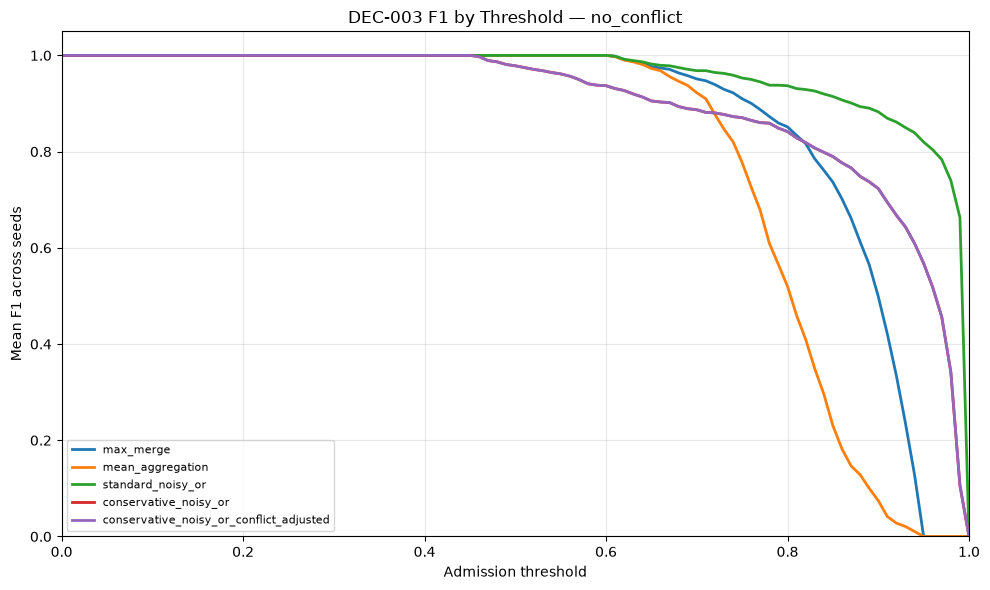

Saved: E:\slde-aft\outputs\dec003_scaled\f1_by_threshold_no_conflict.png


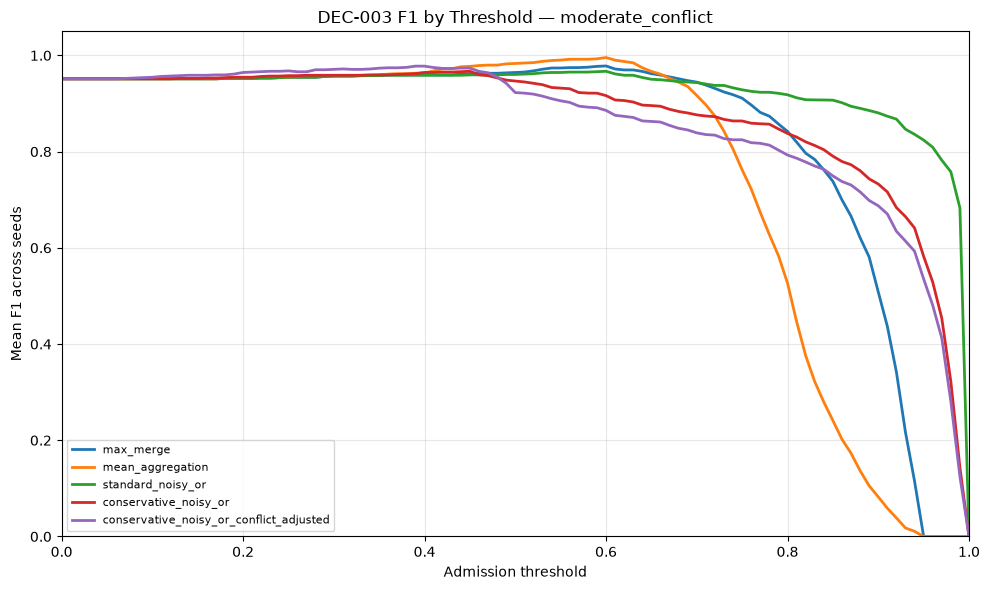

Saved: E:\slde-aft\outputs\dec003_scaled\f1_by_threshold_moderate_conflict.png


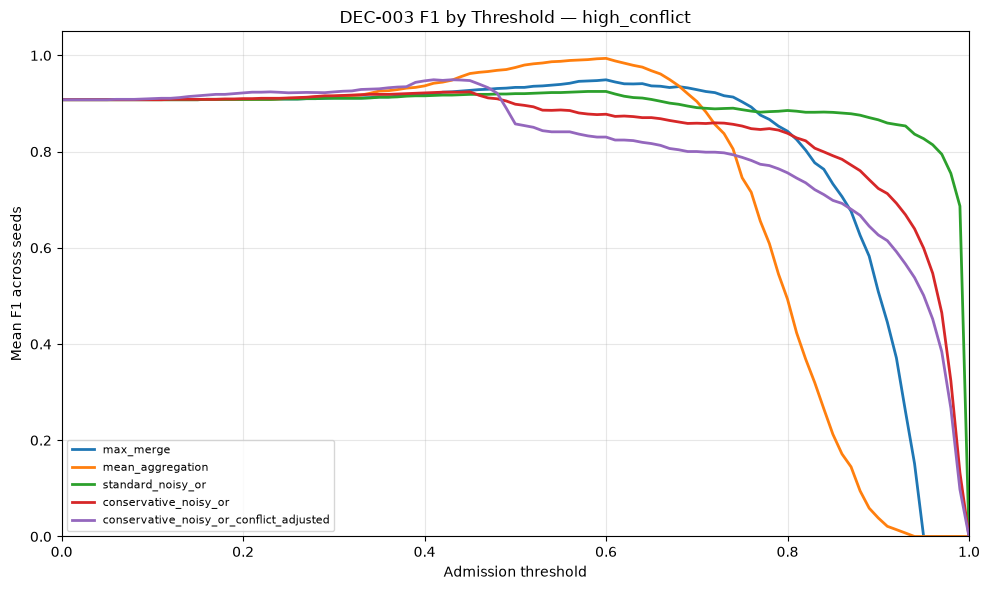

Saved: E:\slde-aft\outputs\dec003_scaled\f1_by_threshold_high_conflict.png


In [22]:
f1_plot_df = (
    threshold_sweep_all_df
    .groupby(["scenario", "method", "threshold"])
    .agg(
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
    )
    .reset_index()
)

for scenario_name in SCENARIOS:
    scenario_df = f1_plot_df[
        f1_plot_df["scenario"] == scenario_name
    ]

    plt.figure(figsize=(10, 6))

    for method_name in methods:
        method_df = scenario_df[
            scenario_df["method"] == method_name
        ].sort_values("threshold")

        plt.plot(
            method_df["threshold"],
            method_df["mean_f1"],
            linewidth=2,
            label=method_name,
        )

    plt.xlabel("Admission threshold")
    plt.ylabel("Mean F1 across seeds")
    plt.title(
        f"DEC-003 F1 by Threshold — {scenario_name}"
    )
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, loc="best")
    plt.tight_layout()

    plot_path = output_dir / f"f1_by_threshold_{scenario_name}.png"

    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", plot_path)


Scenario: no_conflict
Non-empty method-bin points: 24


,scenario,method,bin_lower,bin_upper,total_count,mean_confidence,empirical_accuracy
0,no_conflict,conservative_noisy_or,0.4,0.5,24,0.4735,1.0
1,no_conflict,conservative_noisy_or,0.5,0.6,43,0.5506,1.0
2,no_conflict,conservative_noisy_or,0.6,0.7,48,0.6446,1.0
3,no_conflict,conservative_noisy_or,0.7,0.8,40,0.7574,1.0
4,no_conflict,conservative_noisy_or,0.8,0.9,91,0.8507,1.0
5,no_conflict,conservative_noisy_or,0.9,1.0,322,0.9625,1.0
6,no_conflict,conservative_noisy_or_conflict_adjusted,0.4,0.5,24,0.4735,1.0
7,no_conflict,conservative_noisy_or_conflict_adjusted,0.5,0.6,43,0.5506,1.0
8,no_conflict,conservative_noisy_or_conflict_adjusted,0.6,0.7,48,0.6446,1.0
9,no_conflict,conservative_noisy_or_conflict_adjusted,0.7,0.8,40,0.7574,1.0


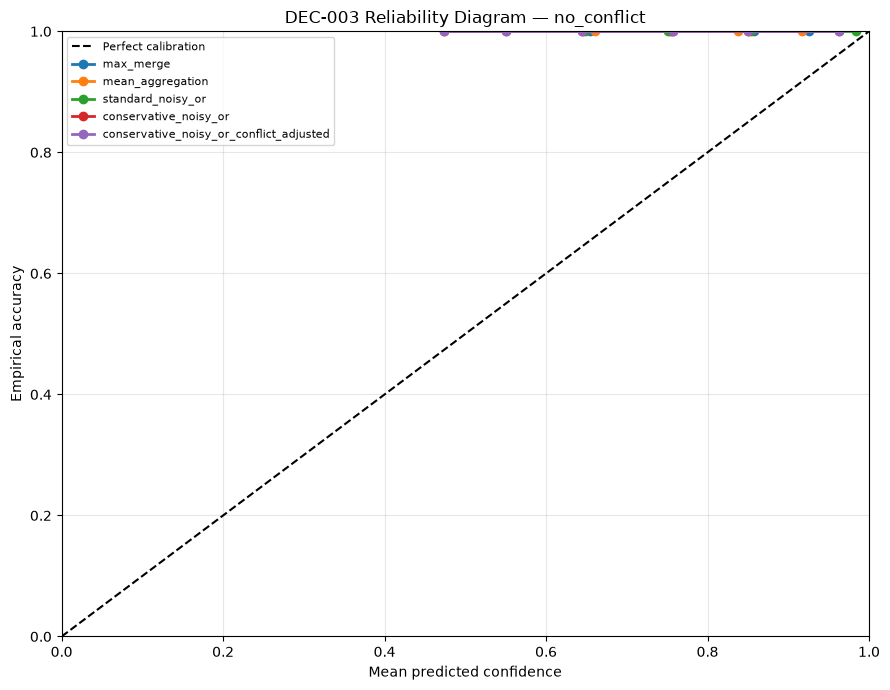

Saved reliability diagram to: E:\slde-aft\outputs\dec003_scaled\reliability_diagram_no_conflict.png

Scenario: moderate_conflict
Non-empty method-bin points: 46


,scenario,method,bin_lower,bin_upper,total_count,mean_confidence,empirical_accuracy
0,moderate_conflict,conservative_noisy_or,0.1,0.2,4,0.1626,0.0000
1,moderate_conflict,conservative_noisy_or,0.2,0.3,5,0.2320,0.0000
2,moderate_conflict,conservative_noisy_or,0.3,0.4,7,0.3774,0.0000
3,moderate_conflict,conservative_noisy_or,0.4,0.5,29,0.4688,0.8276
4,moderate_conflict,conservative_noisy_or,0.5,0.6,46,0.5513,0.8261
5,moderate_conflict,conservative_noisy_or,0.6,0.7,49,0.6518,0.8776
6,moderate_conflict,conservative_noisy_or,0.7,0.8,50,0.7599,0.8200
7,moderate_conflict,conservative_noisy_or,0.8,0.9,94,0.8524,0.9149
8,moderate_conflict,conservative_noisy_or,0.9,1.0,330,0.9627,0.9848
9,moderate_conflict,conservative_noisy_or_conflict_adjusted,0.0,0.1,4,0.0813,0.0000


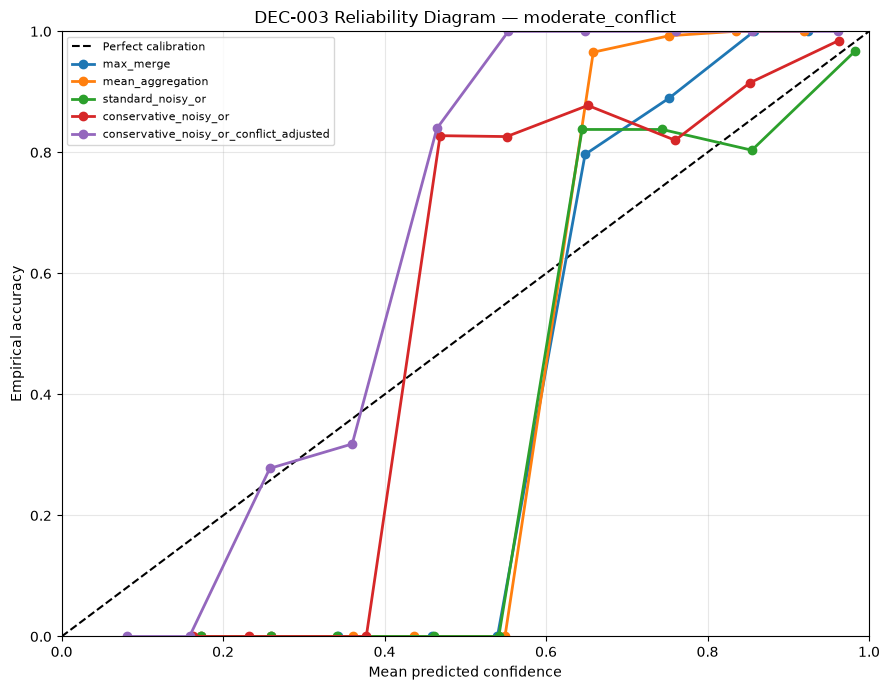

Saved reliability diagram to: E:\slde-aft\outputs\dec003_scaled\reliability_diagram_moderate_conflict.png

Scenario: high_conflict
Non-empty method-bin points: 46


,scenario,method,bin_lower,bin_upper,total_count,mean_confidence,empirical_accuracy
0,high_conflict,conservative_noisy_or,0.1,0.2,3,0.1649,0.0000
1,high_conflict,conservative_noisy_or,0.2,0.3,8,0.2626,0.0000
2,high_conflict,conservative_noisy_or,0.3,0.4,8,0.3506,0.0000
3,high_conflict,conservative_noisy_or,0.4,0.5,35,0.4697,0.8571
4,high_conflict,conservative_noisy_or,0.5,0.6,47,0.5390,0.7021
5,high_conflict,conservative_noisy_or,0.6,0.7,43,0.6477,0.6744
6,high_conflict,conservative_noisy_or,0.7,0.8,66,0.7603,0.5909
7,high_conflict,conservative_noisy_or,0.8,0.9,130,0.8514,0.8154
8,high_conflict,conservative_noisy_or,0.9,1.0,336,0.9634,0.9673
9,high_conflict,conservative_noisy_or_conflict_adjusted,0.0,0.1,3,0.0825,0.0000


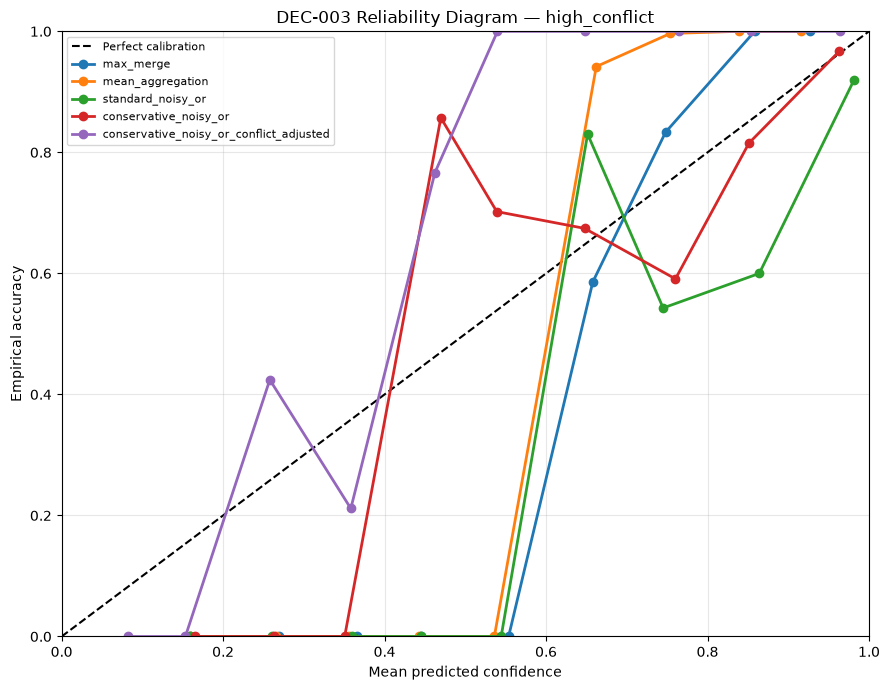

Saved reliability diagram to: E:\slde-aft\outputs\dec003_scaled\reliability_diagram_high_conflict.png


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for scenario_name in SCENARIOS:
    scenario_calibration_df = calibration_bins_all_df[
        calibration_bins_all_df["scenario"] == scenario_name
    ].copy()

    plot_rows = []

    for (
        method_name,
        bin_lower,
        bin_upper,
    ), bin_group_df in scenario_calibration_df.groupby(
        ["method", "bin_lower", "bin_upper"]
    ):
        nonempty_bins_df = bin_group_df[
            (bin_group_df["count"] > 0)
            & bin_group_df["mean_confidence"].notna()
            & bin_group_df["empirical_accuracy"].notna()
        ].copy()

        total_count = int(nonempty_bins_df["count"].sum())

        if total_count == 0:
            continue

        weighted_mean_confidence = float(
            np.average(
                nonempty_bins_df["mean_confidence"],
                weights=nonempty_bins_df["count"],
            )
        )

        weighted_empirical_accuracy = float(
            np.average(
                nonempty_bins_df["empirical_accuracy"],
                weights=nonempty_bins_df["count"],
            )
        )

        plot_rows.append({
            "scenario": scenario_name,
            "method": method_name,
            "bin_lower": bin_lower,
            "bin_upper": bin_upper,
            "total_count": total_count,
            "mean_confidence": weighted_mean_confidence,
            "empirical_accuracy": weighted_empirical_accuracy,
        })

    reliability_plot_df = pd.DataFrame(plot_rows)

    print(f"\nScenario: {scenario_name}")
    print("Non-empty method-bin points:", len(reliability_plot_df))

    display(
        reliability_plot_df.sort_values(
            ["method", "bin_lower"]
        ).round(4)
    )

    if reliability_plot_df.empty:
        print("Skipping plot: no non-empty calibration bins.")
        continue

    plt.figure(figsize=(9, 7))

    plt.plot(
        [0.0, 1.0],
        [0.0, 1.0],
        linestyle="--",
        color="black",
        linewidth=1.5,
        label="Perfect calibration",
    )

    for method_name in methods:
        method_plot_df = reliability_plot_df[
            reliability_plot_df["method"] == method_name
        ].sort_values("mean_confidence")

        if method_plot_df.empty:
            continue

        plt.plot(
            method_plot_df["mean_confidence"],
            method_plot_df["empirical_accuracy"],
            marker="o",
            linewidth=2,
            label=method_name,
        )

    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Empirical accuracy")
    plt.title(
        f"DEC-003 Reliability Diagram — {scenario_name}"
    )
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, loc="best")
    plt.tight_layout()

    plot_path = output_dir / (
        f"reliability_diagram_{scenario_name}.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved reliability diagram to:", plot_path)

In [27]:
all_reliability_plot_rows = []

for scenario_name in SCENARIOS:
    scenario_calibration_df = calibration_bins_all_df[
        calibration_bins_all_df["scenario"] == scenario_name
    ].copy()

    for (
        method_name,
        bin_lower,
        bin_upper,
    ), bin_group_df in scenario_calibration_df.groupby(
        ["method", "bin_lower", "bin_upper"]
    ):
        nonempty_bins_df = bin_group_df[
            (bin_group_df["count"] > 0)
            & bin_group_df["mean_confidence"].notna()
            & bin_group_df["empirical_accuracy"].notna()
        ].copy()

        total_count = int(nonempty_bins_df["count"].sum())

        if total_count == 0:
            continue

        all_reliability_plot_rows.append({
            "scenario": scenario_name,
            "method": method_name,
            "bin_lower": bin_lower,
            "bin_upper": bin_upper,
            "total_count": total_count,
            "mean_confidence": float(
                np.average(
                    nonempty_bins_df["mean_confidence"],
                    weights=nonempty_bins_df["count"],
                )
            ),
            "empirical_accuracy": float(
                np.average(
                    nonempty_bins_df["empirical_accuracy"],
                    weights=nonempty_bins_df["count"],
                )
            ),
        })

reliability_plot_all_df = pd.DataFrame(
    all_reliability_plot_rows
)

reliability_plot_data_path = (
    output_dir / "reliability_diagram_points.csv"
)

reliability_plot_all_df.to_csv(
    reliability_plot_data_path,
    index=False,
    encoding="utf-8",
)

print("Saved reliability-diagram points to:", reliability_plot_data_path)
print("Rows saved:", len(reliability_plot_all_df))

Saved reliability-diagram points to: E:\slde-aft\outputs\dec003_scaled\reliability_diagram_points.csv
Rows saved: 116


In [28]:
def build_iteration_logs(
    run_scores_df,
    run_observations_df,
    shrinkage=DEFAULT_SHRINKAGE,
    threshold=0.88,
):
    run_id = run_scores_df["run_id"].iloc[0]

    max_iteration = int(
        run_observations_df["iteration"].max()
    )

    log_rows = []

    for iteration in range(1, max_iteration + 1):
        observed_so_far_df = run_observations_df[
            run_observations_df["iteration"] <= iteration
        ].copy()

        active_triple_keys = set(
            observed_so_far_df["triple_key"].unique()
        )

        active_triples_df = run_scores_df[
            run_scores_df["triple_key"].isin(active_triple_keys)
        ].copy()

        observation_groups = (
            observed_so_far_df
            .groupby("triple_key")["observation_confidence"]
            .apply(list)
            .to_dict()
        )

        active_competitors = (
            active_triples_df
            .groupby("slot_id")["object"]
            .nunique()
            .sub(1)
            .to_dict()
        )

        for _, triple in active_triples_df.iterrows():
            triple_key = triple["triple_key"]
            confidences = observation_groups[triple_key]

            competitor_count = int(
                active_competitors[triple["slot_id"]]
            )

            support = conservative_noisy_or(
                confidences,
                shrinkage=shrinkage,
            )

            final_score = final_confidence(
                confidences=confidences,
                competitor_count=competitor_count,
                shrinkage=shrinkage,
                functional_predicate=bool(
                    triple["functional_predicate"]
                ),
            )

            log_rows.append({
                "experiment_id": triple["experiment_id"],
                "run_id": run_id,
                "scenario": triple["scenario"],
                "seed": triple["seed"],
                "iteration": iteration,
                "triple_key": triple_key,
                "gold_label": triple["gold_label"],
                "functional_predicate": (
                    triple["functional_predicate"]
                ),
                "observation_count_so_far": len(confidences),
                "support": support,
                "competitor_count": competitor_count,
                "final_confidence": final_score,
                "threshold": threshold,
                "above_threshold": final_score >= threshold,
            })

    return pd.DataFrame(log_rows)

In [29]:
iteration_log_frames = []

for run_id, run_scores_df in scores_all_df.groupby("run_id"):
    run_observations_df = observations_all_df[
        observations_all_df["run_id"] == run_id
    ].copy()

    run_logs_df = build_iteration_logs(
        run_scores_df=run_scores_df,
        run_observations_df=run_observations_df,
        shrinkage=DEFAULT_SHRINKAGE,
        threshold=0.88,
    )

    iteration_log_frames.append(run_logs_df)

iteration_logs_df = pd.concat(
    iteration_log_frames,
    ignore_index=True,
)

iteration_logs_path = output_dir / "iteration_logs.csv"

iteration_logs_df.to_csv(
    iteration_logs_path,
    index=False,
    encoding="utf-8",
)

print("Saved iteration logs to:", iteration_logs_path)
print("Rows saved:", len(iteration_logs_df))

Saved iteration logs to: E:\slde-aft\outputs\dec003_scaled\iteration_logs.csv
Rows saved: 9290


In [30]:
iteration_logs_df = iteration_logs_df.sort_values(
    ["run_id", "triple_key", "iteration"]
).copy()

iteration_logs_df["previous_above_threshold"] = (
    iteration_logs_df
    .groupby(["run_id", "triple_key"])["above_threshold"]
    .shift(1)
)

iteration_logs_df["crossed_threshold_up"] = (
    (~iteration_logs_df["previous_above_threshold"].fillna(False))
    & iteration_logs_df["above_threshold"]
)

iteration_logs_df["crossed_threshold_down"] = (
    iteration_logs_df["previous_above_threshold"].fillna(False)
    & (~iteration_logs_df["above_threshold"])
)

convergence_summary_df = (
    iteration_logs_df
    .groupby(["scenario", "seed", "iteration"])
    .agg(
        mean_support=("support", "mean"),
        mean_final_confidence=("final_confidence", "mean"),
        active_triples=("triple_key", "nunique"),
        active_conflicting_triples=(
            "competitor_count",
            lambda values: int((values > 0).sum()),
        ),
        above_threshold_count=("above_threshold", "sum"),
        threshold_crossings_up=("crossed_threshold_up", "sum"),
        threshold_crossings_down=(
            "crossed_threshold_down",
            "sum",
        ),
    )
    .reset_index()
)

convergence_summary_path = output_dir / "convergence_summary.csv"

convergence_summary_df.to_csv(
    convergence_summary_path,
    index=False,
    encoding="utf-8",
)

display(convergence_summary_df.round(4))

print(
    "Saved convergence summary to:",
    convergence_summary_path,
)

,scenario,seed,iteration,mean_support,mean_final_confidence,active_triples,active_conflicting_triples,above_threshold_count,threshold_crossings_up,threshold_crossings_down
0,high_conflict,42,1,0.5352,0.4547,221,142,0,0,0
1,high_conflict,42,2,0.7308,0.6187,221,142,11,11,0
2,high_conflict,42,3,0.7963,0.6705,221,142,84,73,0
3,high_conflict,42,4,0.8165,0.6857,221,142,87,3,0
4,high_conflict,42,5,0.8222,0.6897,221,142,87,0,0
5,high_conflict,43,1,0.5370,0.4615,230,160,0,0,0
6,high_conflict,43,2,0.7346,0.6275,230,160,13,13,0
7,high_conflict,43,3,0.8028,0.6838,230,160,99,86,0
8,high_conflict,43,4,0.8232,0.7007,230,160,102,3,0
9,high_conflict,43,5,0.8287,0.7049,230,160,102,0,0


Saved convergence summary to: E:\slde-aft\outputs\dec003_scaled\convergence_summary.csv


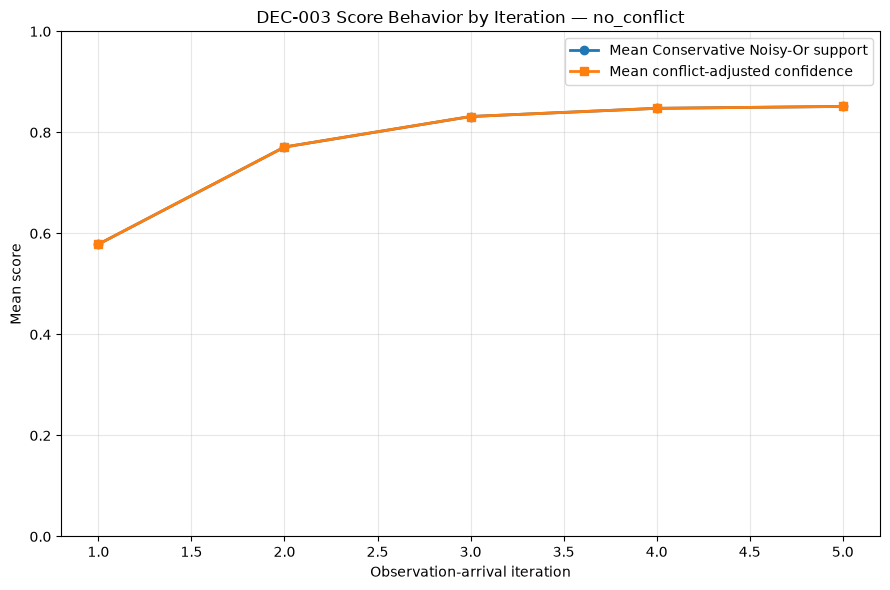

Saved: E:\slde-aft\outputs\dec003_scaled\convergence_scores_no_conflict.png


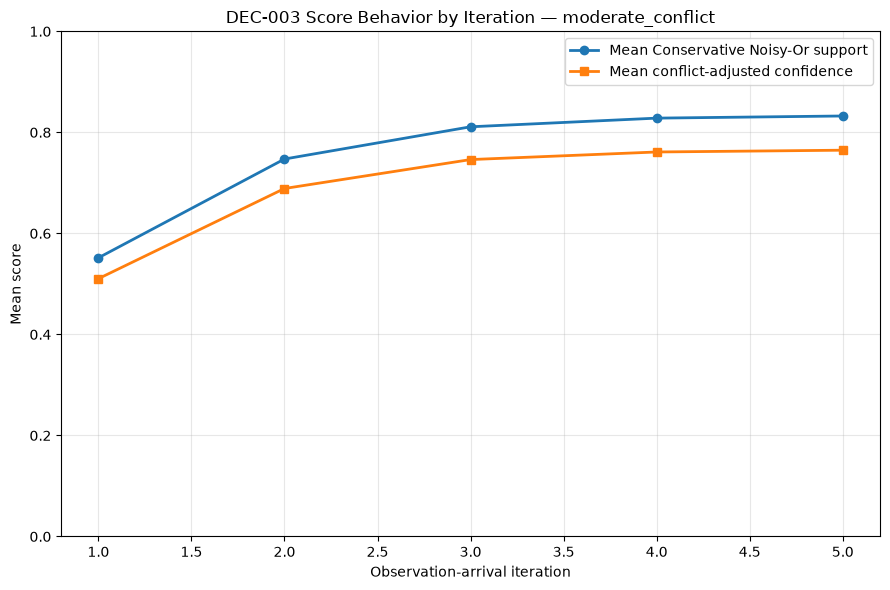

Saved: E:\slde-aft\outputs\dec003_scaled\convergence_scores_moderate_conflict.png


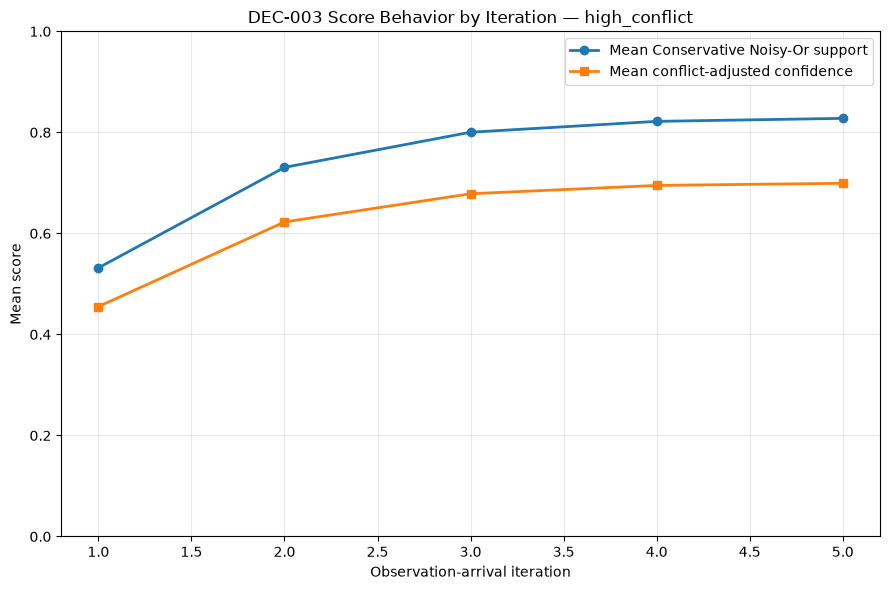

Saved: E:\slde-aft\outputs\dec003_scaled\convergence_scores_high_conflict.png


In [31]:
convergence_plot_df = (
    convergence_summary_df
    .groupby(["scenario", "iteration"])
    .agg(
        mean_support=("mean_support", "mean"),
        mean_final_confidence=(
            "mean_final_confidence",
            "mean",
        ),
        mean_active_triples=("active_triples", "mean"),
        mean_conflicting_triples=(
            "active_conflicting_triples",
            "mean",
        ),
    )
    .reset_index()
)

for scenario_name in SCENARIOS:
    scenario_df = convergence_plot_df[
        convergence_plot_df["scenario"] == scenario_name
    ].sort_values("iteration")

    plt.figure(figsize=(9, 6))

    plt.plot(
        scenario_df["iteration"],
        scenario_df["mean_support"],
        marker="o",
        linewidth=2,
        label="Mean Conservative Noisy-Or support",
    )

    plt.plot(
        scenario_df["iteration"],
        scenario_df["mean_final_confidence"],
        marker="s",
        linewidth=2,
        label="Mean conflict-adjusted confidence",
    )

    plt.xlabel("Observation-arrival iteration")
    plt.ylabel("Mean score")
    plt.title(
        f"DEC-003 Score Behavior by Iteration — {scenario_name}"
    )
    plt.ylim(0.0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plot_path = output_dir / (
        f"convergence_scores_{scenario_name}.png"
    )

    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", plot_path)

In [32]:
manifest = {
    "experiment_id": EXPERIMENT_ID,
    "purpose": (
        "Controlled scaled evaluation of aggregation and "
        "conflict-adjustment rules."
    ),
    "math_authority": (
        "SLDE_AFT_Mathematical_Contribution_Final.pdf"
    ),
    "implementation": "src/pkb_math.py",
    "shrinkage": DEFAULT_SHRINKAGE,
    "seeds": SEEDS,
    "scenarios": SCENARIOS,
    "n_slots_per_run": N_SLOTS,
    "functional_slot_share": FUNCTIONAL_SLOT_SHARE,
    "max_observations_per_triple": MAX_OBSERVATIONS_PER_TRIPLE,
    "positive_confidence_range": POSITIVE_CONFIDENCE_RANGE,
    "negative_confidence_range": NEGATIVE_CONFIDENCE_RANGE,
    "thresholds": {
        "minimum": float(THRESHOLDS.min()),
        "maximum": float(THRESHOLDS.max()),
        "step": 0.01,
        "count": len(THRESHOLDS),
    },
    "calibration_bins": {
        "minimum": float(CALIBRATION_BINS.min()),
        "maximum": float(CALIBRATION_BINS.max()),
        "count": len(CALIBRATION_BINS) - 1,
    },
    "methods": list(methods.keys()),
    "notes": (
        "This is a controlled synthetic aggregation experiment. "
        "It evaluates mathematical behavior and does not replace "
        "CaRB public-benchmark evaluation or full SLDE-AFT ablations."
    ),
}

manifest_df = pd.DataFrame(
    [{"key": key, "value": str(value)} for key, value in manifest.items()]
)

manifest_path = output_dir / "experiment_manifest.csv"

manifest_df.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8",
)

print("Saved experiment manifest to:", manifest_path)

Saved experiment manifest to: E:\slde-aft\outputs\dec003_scaled\experiment_manifest.csv


In [33]:
final_dec003_summary_df = (
    best_thresholds_summary_df
    .merge(
        ece_summary_df,
        on=["scenario", "method"],
        how="left",
    )
    .merge(
        brier_summary_df,
        on=["scenario", "method"],
        how="left",
    )
    .sort_values(
        ["scenario", "mean_f1"],
        ascending=[True, False],
    )
)

display(final_dec003_summary_df.round(6))

final_summary_path = (
    output_dir / "dec003_scaled_results_summary.csv"
)

final_dec003_summary_df.to_csv(
    final_summary_path,
    index=False,
    encoding="utf-8",
)

print("Saved DEC-003 scaled results summary to:", final_summary_path)
print("Rows saved:", len(final_dec003_summary_df))

,scenario,method,mean_best_threshold,std_best_threshold,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_retained,mean_ece,std_ece,mean_brier_score,std_brier_score
3,high_conflict,mean_aggregation,0.586667,0.015275,0.987722,0.006038,1.000000,0.000000,0.993817,0.003051,189.666667,0.253292,0.006033,0.082991,0.002549
1,high_conflict,conservative_noisy_or_conflict_adjusted,0.430000,0.020000,0.965447,0.016260,0.937818,0.012846,0.951285,0.001699,182.000000,0.162721,0.006385,0.104209,0.003802
2,high_conflict,max_merge,0.593333,0.011547,0.903450,0.010802,1.000000,0.000000,0.949254,0.005962,207.333333,0.127246,0.004716,0.085705,0.003850
4,high_conflict,standard_noisy_or,0.570000,0.010000,0.860583,0.010536,1.000000,0.000000,0.925045,0.006068,217.666667,0.109462,0.010474,0.118808,0.007351
0,high_conflict,conservative_noisy_or,0.420000,0.030000,0.859257,0.011744,1.000000,0.000000,0.924273,0.006772,218.000000,0.069781,0.009986,0.116762,0.006523
8,moderate_conflict,mean_aggregation,0.576667,0.032146,0.991096,0.008194,1.000000,0.000000,0.995517,0.004129,187.333333,0.237766,0.009110,0.071875,0.001291
6,moderate_conflict,conservative_noisy_or_conflict_adjusted,0.413333,0.032146,0.982316,0.015315,0.976593,0.008552,0.979352,0.003707,184.666667,0.155775,0.012147,0.076256,0.004754
7,moderate_conflict,max_merge,0.576667,0.032146,0.957026,0.008044,1.000000,0.000000,0.978030,0.004207,194.000000,0.138508,0.006432,0.059629,0.000846
5,moderate_conflict,conservative_noisy_or,0.430000,0.026458,0.936128,0.010564,1.000000,0.000000,0.966990,0.005650,198.333333,0.092499,0.009177,0.077763,0.004731
9,moderate_conflict,standard_noisy_or,0.576667,0.032146,0.936128,0.010564,1.000000,0.000000,0.966990,0.005650,198.333333,0.046054,0.002259,0.062746,0.004313


Saved DEC-003 scaled results summary to: E:\slde-aft\outputs\dec003_scaled\dec003_scaled_results_summary.csv
Rows saved: 15


In [34]:
import json
from pathlib import Path

functional_policy_path = (
    project_root
    / "configs"
    / "functional_predicates_dec003_controlled.json"
)

with functional_policy_path.open(
    "r",
    encoding="utf-8",
) as file:
    functional_policy = json.load(file)

functional_predicates = set(
    functional_policy["functional_predicates"]
)

non_functional_predicates = set(
    functional_policy["non_functional_predicates"]
)

print("Loaded functional predicate policy:")
print("Functional:", sorted(functional_predicates))
print("Non-functional:", sorted(non_functional_predicates))

Loaded functional predicate policy:
Functional: ['belongs_to_category', 'has_color', 'has_noise_cancellation', 'has_price_usd', 'target_market_region']
Non-functional: ['made_of_material']
